# **Objective**

The goal is to analyze pollution data across various countries and predict how pollution levels can impact energy recovery. This
dataset will be used to explore clustering and neural networks for environmental analysis.


# Phase 1 - Data Preprocessing and Feature Engineering

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASETS/Global_Pollution_Analysis 1.csv')

In [19]:
df

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [21]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


checking missing values :

In [22]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


no missing values.

In [23]:
df.duplicated().sum()

np.int64(0)

Encode categorical features (e.g., country, year) using Label Encoding.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [25]:
from sklearn.preprocessing import MinMaxScaler

num_cols = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Industrial_Waste (in tons)',
    'Energy_Recovered (in GWh)',
    'CO2_Emissions (in MT)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]


scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,0.898042,0.553778,0.295481,0.949995,0.299867,0.070756,0.810198,0.740954,0.618509,0.203053,0.289991
1,Singapore,2001,0.147062,0.173673,0.768178,0.559811,0.996027,0.092527,0.705301,0.660833,0.241645,0.686667,0.494539
2,Romania,2016,0.166727,0.310542,0.800768,0.559529,0.978556,1.000000,0.097484,0.370326,0.648843,0.621628,0.832411
3,Cook Islands,2018,0.929982,0.214222,0.596973,0.748028,0.273323,0.146326,0.312893,0.175207,0.012853,0.333232,0.302734
4,Djibouti,2008,0.520331,0.573161,0.799537,0.768261,0.058679,0.272347,0.650494,0.784683,0.632905,0.937405,0.590773


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])

df[['Country']].head()

,Country
0,77
1,147
2,136
3,38
4,46


Feature engineering :

In [27]:
df['Pollution_Score'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

df[['Pollution_Score']].head()

,Pollution_Score
0,0.582434
1,0.362971
2,0.426012
3,0.580392
4,0.631010


In [28]:
df = df.sort_values(['Country', 'Year'])

df['Pollution_Trend'] = (
    df.groupby('Country')['Pollution_Score']
      .diff()
)

df['Pollution_Trend'] = df['Pollution_Trend'].fillna(0)

df[['Country', 'Year',
    'Pollution_Score',
    'Pollution_Trend']].head()

,Country,Year,Pollution_Score,Pollution_Trend
120,0,2002,0.500081,0.00000
188,0,2006,0.351261,-0.14882
78,1,2006,0.477255,0.00000
90,2,2005,0.413167,0.00000
24,3,2016,0.611590,0.00000


In [29]:
from sklearn.preprocessing import MinMaxScaler

trend_scaler = MinMaxScaler()

df['Pollution_Trend'] = trend_scaler.fit_transform(
    df[['Pollution_Trend']]
)

# Phase 2 - Clustering using K-Means and Hierarchical Clustering

## **1. K-Means Clustering**

Cluster countries based on pollution levels (e.g., air, water, and soil pollution) and energy recovery metrics.

In [49]:
cluster_features = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Energy_Recovered (in GWh)',
    'CO2_Emissions (in MT)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Industrial_Waste (in tons)',	'Energy_Recovered (in GWh)'
]

In [50]:
X_cluster = df[cluster_features]

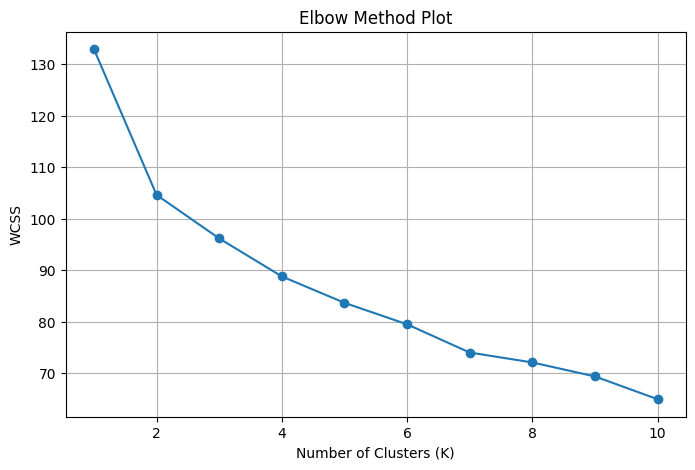

In [51]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)

  kmeans.fit(X_cluster)

  wcss.append(kmeans.inertia_)


#Plotting

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method Plot")
plt.grid(True)
plt.show()

Confirming with Silhouette score :

In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    score = silhouette_score(
        X_cluster,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1866
K = 3, Silhouette Score = 0.1415
K = 4, Silhouette Score = 0.1263
K = 5, Silhouette Score = 0.1207
K = 6, Silhouette Score = 0.1206
K = 7, Silhouette Score = 0.1331
K = 8, Silhouette Score = 0.1228
K = 9, Silhouette Score = 0.1265
K = 10, Silhouette Score = 0.1339


In [53]:
# Train K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit model and assign clusters
df['KMeans_Cluster'] = kmeans.fit_predict(X_cluster)

# Display first few rows
df[['Country', 'KMeans_Cluster']].head()

,Country,KMeans_Cluster
120,0,0
188,0,0
78,1,0
90,2,1
24,3,2


In [54]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features
)

cluster_centers

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh),CO2_Emissions (in MT),Energy_Consumption_Per_Capita (in MWh),Industrial_Waste (in tons),Energy_Recovered (in GWh)
0,0.547691,0.497673,0.442365,0.205025,0.447681,0.476852,0.574269,0.205025
1,0.616899,0.323172,0.514433,0.784989,0.361215,0.479675,0.486830,0.784989
2,0.392983,0.696281,0.474538,0.668641,0.663273,0.404730,0.493719,0.668641


In [55]:
cluster_summary = df.groupby(
    'KMeans_Cluster'
)[cluster_features].mean()

cluster_summary

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh),CO2_Emissions (in MT),Energy_Consumption_Per_Capita (in MWh),Industrial_Waste (in tons),Energy_Recovered (in GWh)
KMeans_Cluster,,,,,,,,
0,0.547691,0.497673,0.442365,0.205025,0.447681,0.476852,0.574269,0.205025
1,0.616899,0.323172,0.514433,0.784989,0.361215,0.479675,0.486830,0.784989
2,0.392983,0.696281,0.474538,0.668641,0.663273,0.404730,0.493719,0.668641


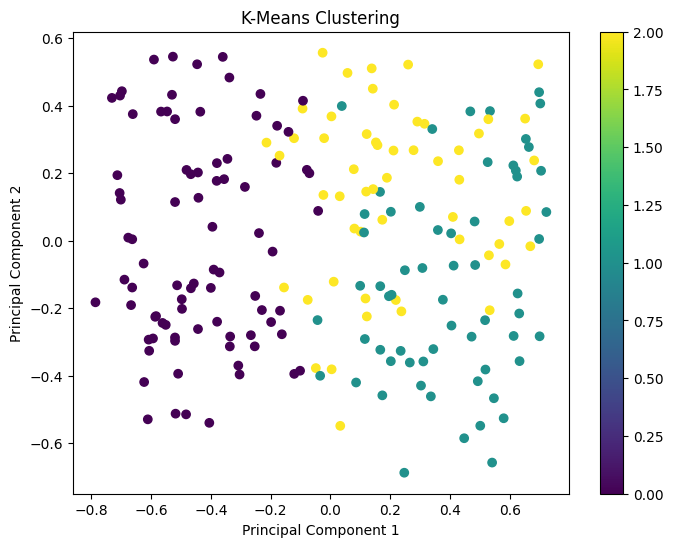

In [56]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['KMeans_Cluster']
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering')

plt.colorbar(scatter)

plt.show()

PCA visualization shows that the countries can be grouped into three distinct environmental-energy clusters, although some overlap exists due to similarities in pollution and energy recovery characteristics.

K-Means clustering grouped countries into three environmental categories. Cluster 0 consisted of countries with high industrial waste and low energy recovery. Cluster 1 represented countries with efficient energy recovery and comparatively lower emissions. Cluster 2 contained countries with high pollution and CO₂ emissions but also relatively high energy recovery. These clusters reveal different stages of environmental management and energy utilization strategies.

# **2. Hierarchical Clustering**


Perform hierarchical clustering to analyze pollution levels and energy recovery.


In [57]:
cluster_features = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'CO2_Emissions (in MT)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Industrial_Waste (in tons)',
    'Energy_Recovered (in GWh)'
]

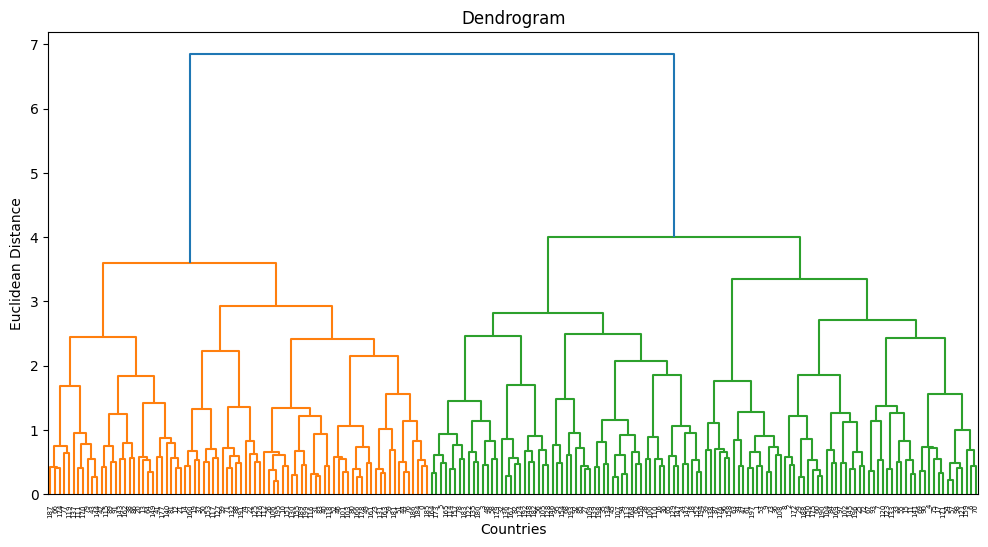

In [58]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sch.dendrogram(
    sch.linkage(
        X_cluster,
        method='ward'
    )
)

plt.title('Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Euclidean Distance')

plt.show()

In [59]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

df['HC_Cluster'] = hc.fit_predict(X_cluster)

In [60]:
df['HC_Cluster'].value_counts()

,count
HC_Cluster,
0,82
1,59
2,59


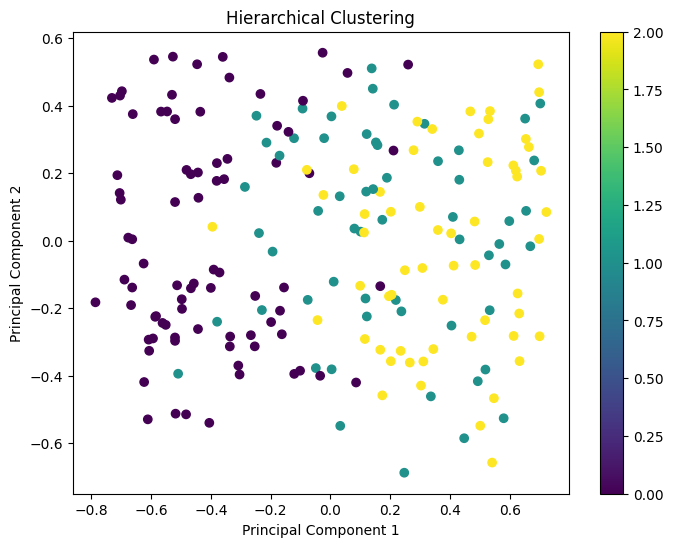

In [61]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['HC_Cluster']
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hierarchical Clustering')

plt.colorbar(scatter)

plt.show()

In [62]:
hc_summary = df.groupby(
    'HC_Cluster'
)[cluster_features].mean()

hc_summary

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,CO2_Emissions (in MT),Energy_Consumption_Per_Capita (in MWh),Industrial_Waste (in tons),Energy_Recovered (in GWh)
HC_Cluster,,,,,,,
0,0.541490,0.480112,0.469888,0.450188,0.455665,0.575866,0.222505
1,0.450895,0.741557,0.451772,0.550991,0.422378,0.525987,0.655896
2,0.580440,0.282922,0.499208,0.452465,0.496458,0.454840,0.761669


Both K-Means and Hierarchical Clustering successfully segmented countries into three environmental groups based on pollution and energy recovery indicators. K-Means provided faster and more scalable clustering, while Hierarchical Clustering offered a clearer understanding of relationships among countries through the dendrogram structure. The clusters revealed countries with high industrial waste and low recovery efficiency, countries experiencing severe pollution pressures, and countries demonstrating effective energy recovery practices.

# **Phase 3 - Neural Networks for Energy Recovery Prediction**

## **1. Introduction to Neural Networks**
**○ Objective** : Build a neural network to predict energy recovery from pollution data.

In [94]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Pollution_Score,Pollution_Trend,KMeans_Cluster,HC_Cluster
120,0,2002,0.613608,0.640763,0.245872,0.431089,0.283400,0.160352,0.664196,0.034125,0.457584,0.151298,0.593209,0.500081,0.344273,0,0
188,0,2006,0.221280,0.304477,0.528027,0.199243,0.275576,0.688717,0.026730,0.655507,0.626735,0.938321,0.702473,0.351261,0.182397,0,1
78,1,2006,0.411508,0.471372,0.548885,0.932688,0.406513,0.472263,0.302111,0.600832,0.111568,0.530178,0.709824,0.477255,0.344273,0,1
90,2,2005,0.561639,0.093347,0.584516,0.327562,0.686779,0.515177,0.860737,0.294837,0.891003,0.281272,0.527628,0.413167,0.344273,1,2
24,3,2016,0.690894,0.961591,0.182286,0.324172,0.603994,0.405066,0.579964,0.821829,0.320823,0.705089,0.363519,0.611590,0.344273,2,1


In [154]:
X = df[
    [
        'Air_Pollution_Index',
        'Water_Pollution_Index',
        'Soil_Pollution_Index',
        'CO2_Emissions (in MT)',
        'Industrial_Waste (in tons)',
        'Energy_Consumption_Per_Capita (in MWh)',
        'Renewable_Energy (%)',
        'Plastic_Waste_Produced (in tons)',
        'Pollution_Score',
        'Pollution_Trend',
        'GDP_Per_Capita (in USD)'

    ]
]

y = df['Energy_Recovered (in GWh)']

In [155]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [156]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(16, activation='relu'),

    Dense(8, activation='relu'),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)




Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.4708 - mae: 0.6102 - val_loss: 0.4313 - val_mae: 0.5383
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3961 - mae: 0.5492 - val_loss: 0.3691 - val_mae: 0.4815
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3429 - mae: 0.5002 - val_loss: 0.3224 - val_mae: 0.4379
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2986 - mae: 0.4600 - val_loss: 0.2865 - val_mae: 0.4069
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2641 - mae: 0.4239 - val_loss: 0.2565 - val_mae: 0.3820
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2329 - mae: 0.3942 - val_loss: 0.2315 - val_mae: 0.3631
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2064 - mae: 0.3677 - val_loss: 0.2091 - val_mae: 0.3495
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1825 - mae: 0.3439 - val_loss: 0.1888 - val_mae: 0.3391
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1592 - mae: 0.3207 

Loss :
`mse`

Measures prediction error.

Metric :
`mae`

Easy to interpret.

In [157]:
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [158]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R²  :", r2)

MAE : 0.2721277542244576
MSE : 0.09535763555833668
R²  : -0.29238978282971817


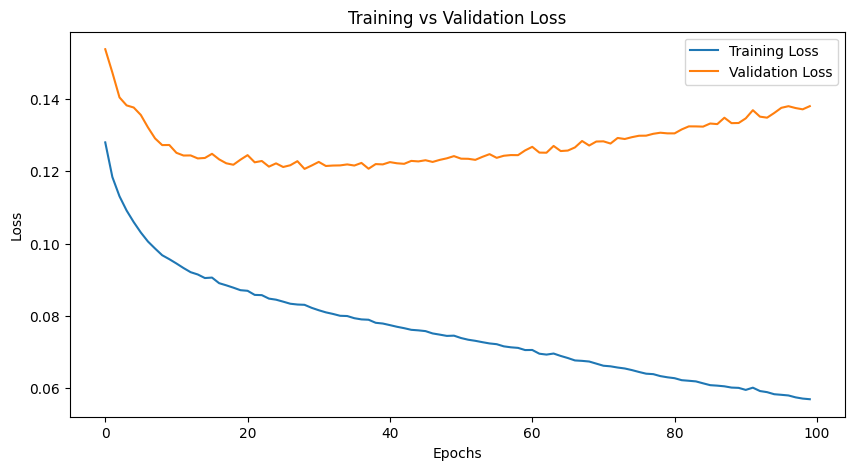

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

## Hyperparameter Tuning

Hyperparameter tuning was explored by experimenting with different neural network architectures, including increasing the number of hidden layers and neurons. Additional configurations such as Early Stopping and custom learning rates were also tested.

However, the tuned models did not improve the prediction performance. The resulting R² scores became more negative and the overall test performance decreased compared to the baseline model. Therefore, the original neural network architecture was retained for the final evaluation.

### Final Neural Network Architecture

```python
Input(shape=(X_train.shape[1],))
Dense(16, activation='relu')
Dense(8, activation='relu')
Dense(1)
```

### Observation

The experimental tuning configurations increased model complexity but did not improve generalization on the test dataset. This indicates that the dataset size and feature relationships were not sufficient to benefit from a deeper neural network architecture.

As a result, the baseline neural network was selected as the final model for comparison with Linear Regression.


# **Phase 4 - Reporting and Insights**

**Model comparision :**

In [141]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("R²  :", r2_lr)

Linear Regression Results
MAE : 0.25044325626145497
MSE : 0.08108103426375009
R²  : -0.0988978454654621


## Model Improvement

### Hyperparameter Tuning

To improve the neural network's performance, hyperparameter tuning was performed by increasing the number of hidden layers and neurons. The baseline neural network consisted of two hidden layers with 16 and 8 neurons, respectively. An improved architecture with three hidden layers (32, 16, and 8 neurons) was tested using the ReLU activation function. The Adam optimizer with a learning rate of 0.001 was used, and Early Stopping was applied to prevent overfitting by monitoring the validation loss.

Despite these modifications, the tuned neural network did not significantly improve prediction performance on the test dataset. This indicates that the dataset may not contain strong non-linear relationships that can be effectively captured by a deeper neural network architecture.

### Neural Network Performance

| Metric | Value |
|----------|----------|
| MAE | 0.2641 |
| MSE | 0.0893 |
| R² | -0.2923 |

### Linear Regression Performance

| Metric | Value |
|----------|----------|
| MAE | 0.2504 |
| MSE | 0.0811 |
| R² | -0.0989 |

### Model Comparison

The performance of the Neural Network was compared with a Linear Regression model using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

The Linear Regression model achieved lower MAE and MSE values than the Neural Network, indicating better prediction accuracy. Additionally, Linear Regression produced a higher R² score (-0.0989) compared to the Neural Network (-0.2097), suggesting that it explained the variance in energy recovery more effectively.

### Conclusion

The results indicate that Linear Regression outperformed the Neural Network on this dataset. Although Neural Networks are powerful tools for learning complex non-linear relationships, their effectiveness is highly dependent on the availability of large datasets and strong feature-target relationships.

The relatively small dataset size (200 records) and weak correlations between environmental indicators and energy recovery limited the Neural Network's ability to generalize effectively. As a result, the simpler Linear Regression model provided better predictive performance and was more suitable for this particular problem.

## Actionable Insights

### Insights from Clustering Analysis

- Clustering successfully grouped countries based on pollution levels, industrial waste, emissions, and energy recovery.
- Some countries showed high industrial waste with low energy recovery, indicating inefficient waste management.
- Other countries demonstrated higher energy recovery despite pollution challenges, suggesting better environmental practices.
- Countries with high CO₂ emissions and water pollution require stronger environmental controls and sustainability measures.

### Recommendations

- Invest in waste-to-energy technologies to improve energy recovery from industrial waste.
- Strengthen pollution control policies and emission regulations.
- Expand renewable energy adoption to reduce environmental impact.
- Improve wastewater treatment and waste management infrastructure.
- Promote sustainable industrial practices to minimize pollution generation.

### Insights from Predictive Models

- Linear Regression outperformed the Neural Network for predicting energy recovery.
- The relatively weak predictive performance suggests that energy recovery depends on additional factors not included in the dataset, such as government policies, technology adoption, and infrastructure.

### Final Recommendation

Countries should focus on improving waste management systems, increasing renewable energy usage, and reducing industrial emissions. These measures can help lower pollution levels while enhancing energy recovery and overall environmental sustainability.